# 04 — RNA-seq preprocessing and sample QC

Quality control of the gene-level count matrix by PCA, removal of libraries flagged
by FastQC, and export of the filtered raw-count matrix for differential expression.

**Position in the pipeline**
`03_export_contrasts.R` -> **this notebook** ->
`09_tf_motif_enrichment_analysis.Rmd` -> 10_prepare_carnival_networks.R

**Inputs**
- `gene_counts.tsv` — gene x sample raw counts; 
- `metadata.tsv` — one row per library. Comma-separated despite the `.tsv` extension.

**Outputs**
- `gene_counts_PP.tsv` — raw counts, QC-passing samples only. Input to DESeq2.
- `metadata_PP.tsv` — matching sample table.
- `results/*.pdf` — QC figures.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load data
data = pd.read_csv("gene_counts.tsv", sep="\t")
# Set gene_id as index
data = data.set_index("gene_id")

MARKDOWN — above the metadata cell

## 1. Sample table

`BBS1` samples are excluded here: `not part of this manuscript`. All downstream counts refer to the
WT / Light / Dark subset.

In [ ]:
#load metadata
metadata = pd.read_csv("metadata.tsv", sep=",", index_col=0)
metadata.index.name = "sample"
metadata.head()
metadata.to_csv("metadata_from_PCA.tsv")
#filter out BBS1 samples
metadata = metadata[metadata["condition"] != "BBS1"]

## 2. Transformation for QC

`log2(count + 1)` followed by gene-wise z-scaling. This is for visualisation only —
DESeq2 downstream models raw counts and does its own normalisation.

In [ ]:
# Align counts and metadata
counts = data[metadata.index]

# Log transform 
counts_log = np.log2(counts + 1)

# Transpose for PCA
X = counts_log.T

# Scale
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Build plotting dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=metadata.index
).join(metadata)

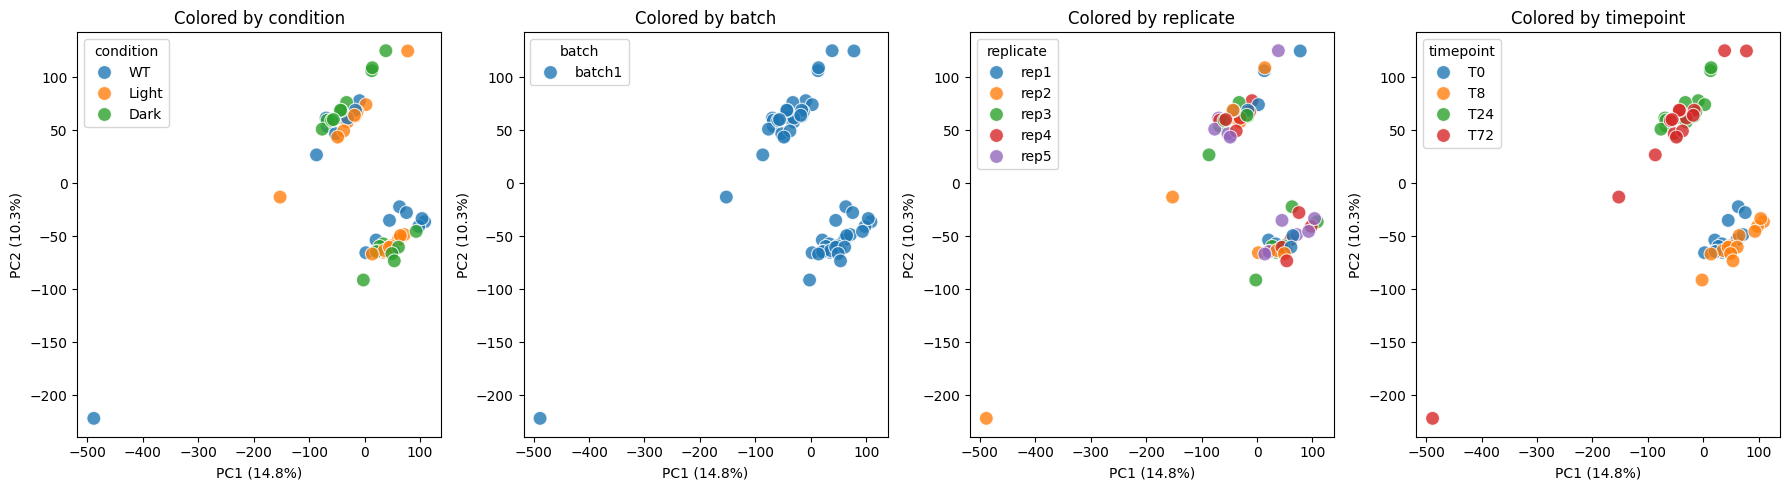

In [5]:
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
color_vars = ["condition", "batch", "replicate", "timepoint"]  # Adjust based on your metadata columns
for ax, var in zip(axes, color_vars):
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue=var,
        s=100,
        ax=ax,
        alpha = 0.8
    )
    
    ax.set_title(f"Colored by {var}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.tight_layout()
plt.show()

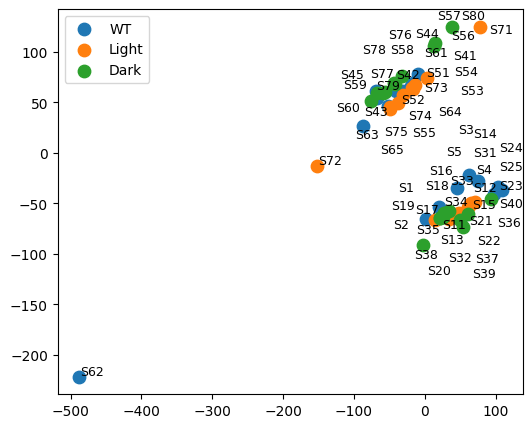

In [6]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(6, 5))

texts = []

for group in pca_df["condition"].unique():
    subset = pca_df[pca_df["condition"] == group]
    ax.scatter(subset["PC1"], subset["PC2"], label=group, s=80)

for sample, row in pca_df.iterrows():
    texts.append(
        ax.text(row["PC1"], row["PC2"], sample, fontsize=9)
    )

adjust_text(texts)

ax.legend()
plt.show()

## 3. Removal of low-quality libraries

Five libraries (S3, S10, S29, S62, S67) are excluded. Flagged by FastQC 

In [ ]:
#Filter low quality replicates (low gene count flagged by FastQC)

if all(col in counts_log.columns for col in ["S10", "S62", "S3", "S29", "S67"]) and all(idx in metadata.index for idx in ["S10", "S62", "S3", "S29", "S67"]):
    counts_log.drop(columns=["S10", "S62", "S3", "S29", "S67"], inplace=True)
    metadata.drop(index=["S10", "S62", "S3", "S29", "S67"], inplace=True)
counts_log = data[metadata.index]
X = counts_log.T

# Scale
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Build plotting dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=metadata.index
).join(metadata)

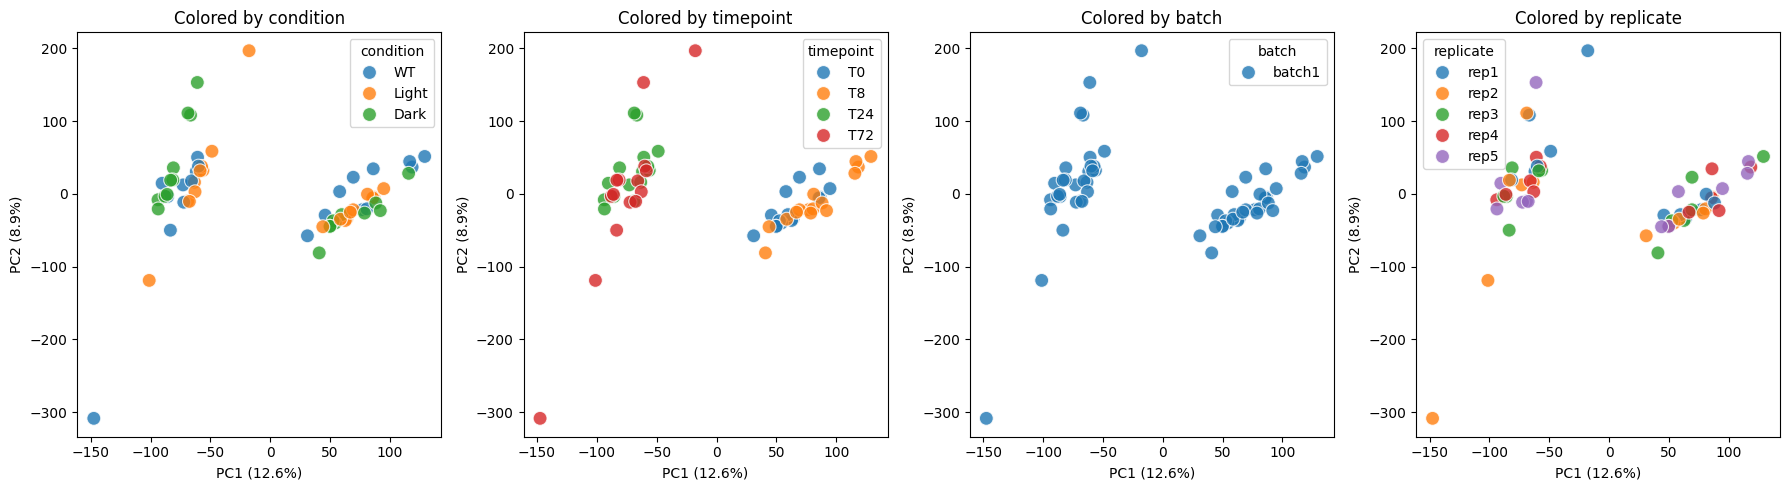

In [9]:
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
color_vars = ['condition', 'timepoint', 'batch', 'replicate']  # Adjust based on your metadata columns
for ax, var in zip(axes, color_vars):
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue=var,
        s=100,
        ax=ax,
        alpha = 0.8
    )
    
    ax.set_title(f"Colored by {var}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.tight_layout()
plt.show()

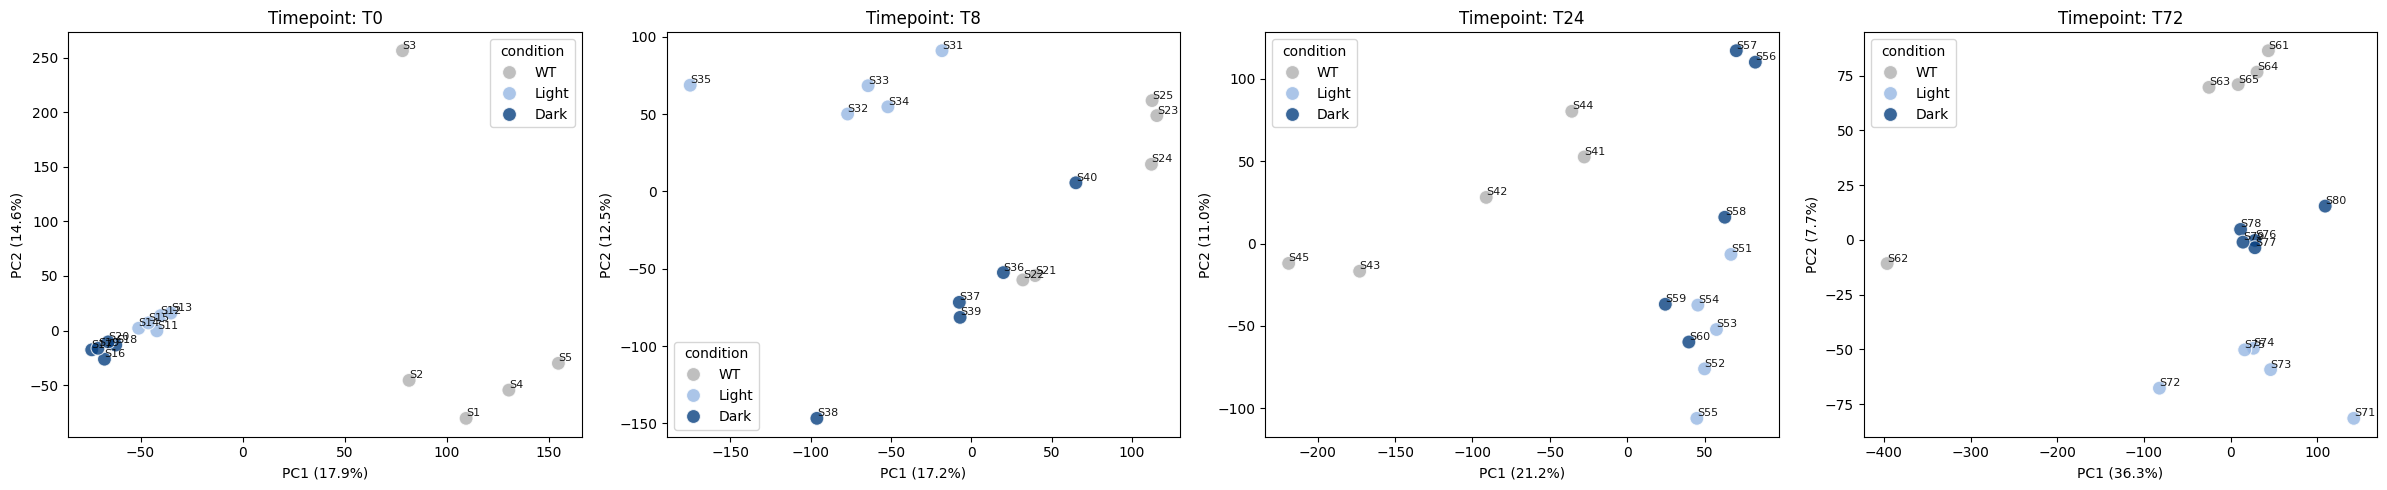

In [14]:
# Timepoint-specific PCAs
timepoints = metadata["timepoint"].unique()

fig, axes = plt.subplots(1, len(timepoints), figsize=(6 * len(timepoints), 5))

for ax, tp in zip(axes, timepoints):
    # Subset samples for this timepoint
    tp_samples = metadata[metadata["timepoint"] == tp].index
    tp_counts = data[tp_samples]
    tp_meta = metadata.loc[tp_samples]
    
    # Log transform
    tp_counts_log = np.log2(tp_counts + 1)
    
    # Transpose and scale
    X_tp = tp_counts_log.T
    X_tp_scaled = StandardScaler().fit_transform(X_tp)
    
    # PCA
    pca_tp = PCA(n_components=2)
    X_tp_pca = pca_tp.fit_transform(X_tp_scaled)
    
    # Build plotting dataframe
    tp_pca_df = pd.DataFrame(
        X_tp_pca,
        columns=["PC1", "PC2"],
        index=tp_samples
    ).join(tp_meta)
    
    # Add sample name labels
    for sample, row in tp_pca_df.iterrows():
        ax.text(
            row["PC1"], row["PC2"],
            str(sample),
            fontsize=8,
            alpha=0.9,
            ha="left", va="bottom"
        )
    palette = {
        "WT": "#AFAFAF",
        "Light": "#96B7E3",
        "Dark": "#074080"
    }
    # Plot colored by condition
    sns.scatterplot(
        data=tp_pca_df,
        x="PC1",
        y="PC2",
        hue="condition",
        s=100,
        ax=ax,
        alpha=0.8,
        palette=palette
    )
    
    ax.set_title(f"Timepoint: {tp}")
    ax.set_xlabel(f"PC1 ({pca_tp.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_tp.explained_variance_ratio_[1]*100:.1f}%)")

plt.tight_layout()
plt.show()

In [11]:
counts_log.to_csv("gene_counts_PP.tsv", sep="\t")